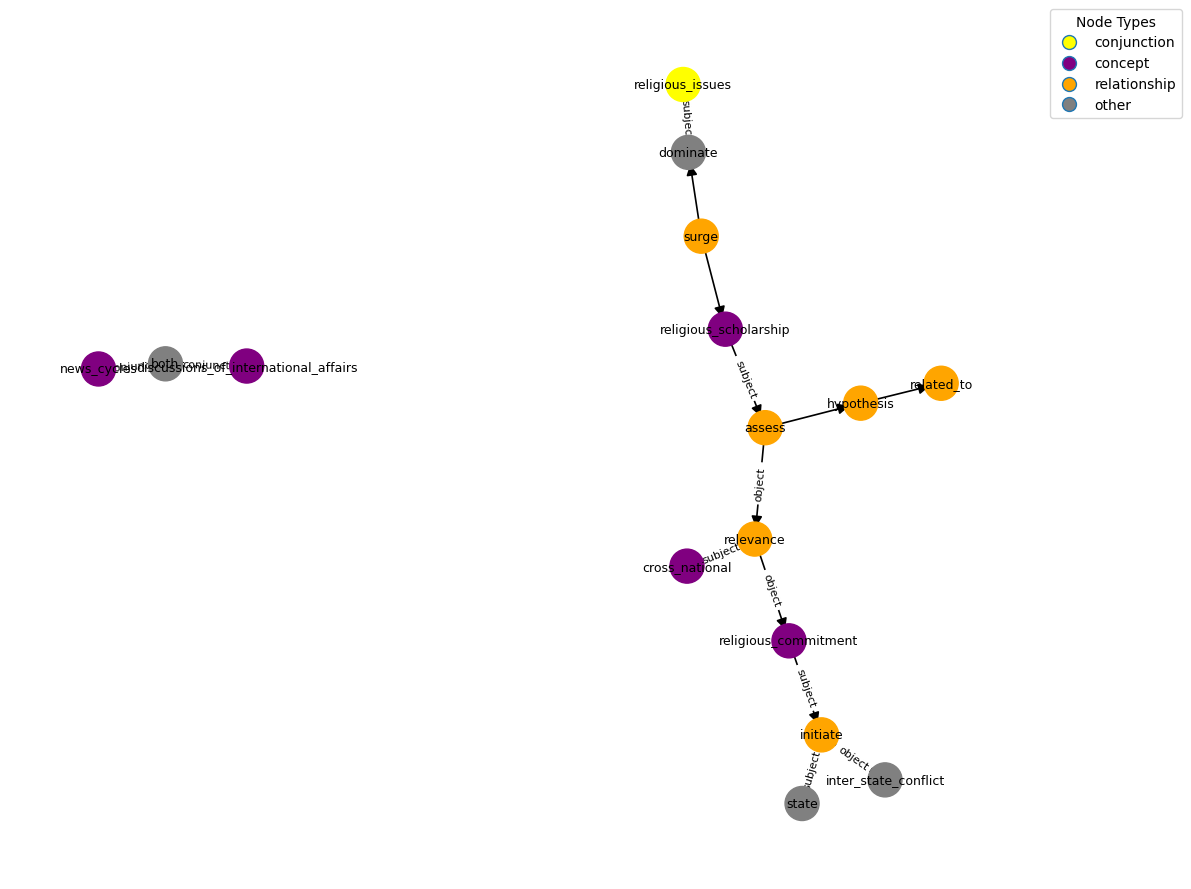

Loaded graph: Graph
Nodes: 16 | Edges: 14
Saved image to: C:\WorldView\worldview\w0rldview\graphML.png


In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# GraphML file path
GRAPHML_PATH = Path(r"C:\WorldView\worldview\w0rldview\test1_v2.graphml")   # Windows
# GRAPHML_PATH = Path("/Users/nick/Documents/my_graph.graphml")    # Mac

NODE_LABEL_ATTR = None
EDGE_LABEL_ATTR = "Edge_Type"
NODE_TYPE_ATTR = "Node_Type"

OUT_IMAGE = Path("graphML.png")

def main():
    if not GRAPHML_PATH.exists():
        raise FileNotFoundError(f"GraphML file not found: {GRAPHML_PATH}")

    G = nx.read_graphml(GRAPHML_PATH)
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 9))

    # --- Node color by type ---
    node_type_colors = {
        "concept": "purple",
        "people": "blue",
        "location": "green",
        "conjunction": "yellow",
        "relationship": "orange",
        #"subject": "red",
        "target": "red",
        "other": "gray",
    }

    # --- Build node color list ---
    node_colors = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        node_colors.append(node_type_colors.get(t, node_type_colors["other"]))

    # --- Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos,
        node_size=600,
        node_color=node_colors
    )

    # --- Draw edges with arrowheads ---
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.2
    )

    # --- Node labels ---
    if NODE_LABEL_ATTR:
        node_labels = {n: str(G.nodes[n].get(NODE_LABEL_ATTR, n)) for n in G.nodes()}
    else:
        node_labels = {n: str(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)

    # --- Edge labels ---
    if EDGE_LABEL_ATTR:
        edge_labels = {}
        if G.is_multigraph():
            for u, v, k, data in G.edges(keys=True, data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])
        else:
            for u, v, data in G.edges(data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])

        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # --- Legend ---
    present_types = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        if t not in present_types:
            present_types.append(t)

    legend_handles = []
    for t in present_types:
        c = node_type_colors.get(t, node_type_colors["other"])
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='',
                   markerfacecolor=c, markersize=10, label=t)
        )

    if legend_handles:
        plt.legend(handles=legend_handles, title="Node Types",
                   loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_IMAGE, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Loaded graph: {G.__class__.__name__}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Saved image to: {OUT_IMAGE.resolve()}")

if __name__ == "__main__":
    main()


Loaded Graph 1: test2.graphml
Loaded Graph 2: test1.graphml

--- NODE COMPARISON ---
Matching nodes:
  assess
  both
  cross_national
  discussions_of_international_affairs
  dominate
  hypothesis
  initiate
  inter_state_conflict
  news_cycles
  related_to
  relevance
  religious_commitment
  religious_issues
  religious_scholarship
  state
  surge

--- EDGE COMPARISON ---
Matching edges:
  ('assess', 'hypothesis')
  ('assess', 'relevance')
  ('discussions_of_international_affairs', 'both')
  ('hypothesis', 'related_to')
  ('initiate', 'inter_state_conflict')
  ('initiate', 'state')
  ('news_cycles', 'both')
  ('relevance', 'cross_national')
  ('relevance', 'religious_commitment')
  ('religious_commitment', 'initiate')
  ('religious_issues', 'dominate')
  ('religious_scholarship', 'assess')
  ('surge', 'dominate')
  ('surge', 'religious_scholarship')

Edges only in first graph:
  ('dominate', 'both')

--- SUMMARY ---
Graph 1: 16 nodes, 15 edges
Graph 2: 16 nodes, 14 edges
The two gra

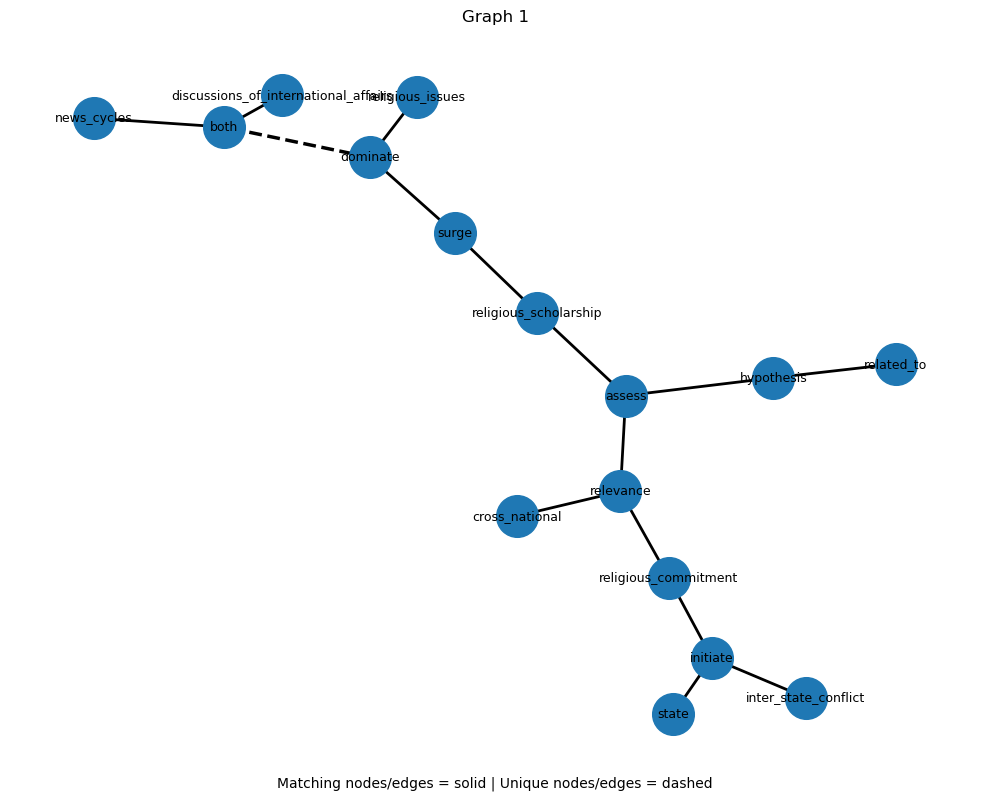

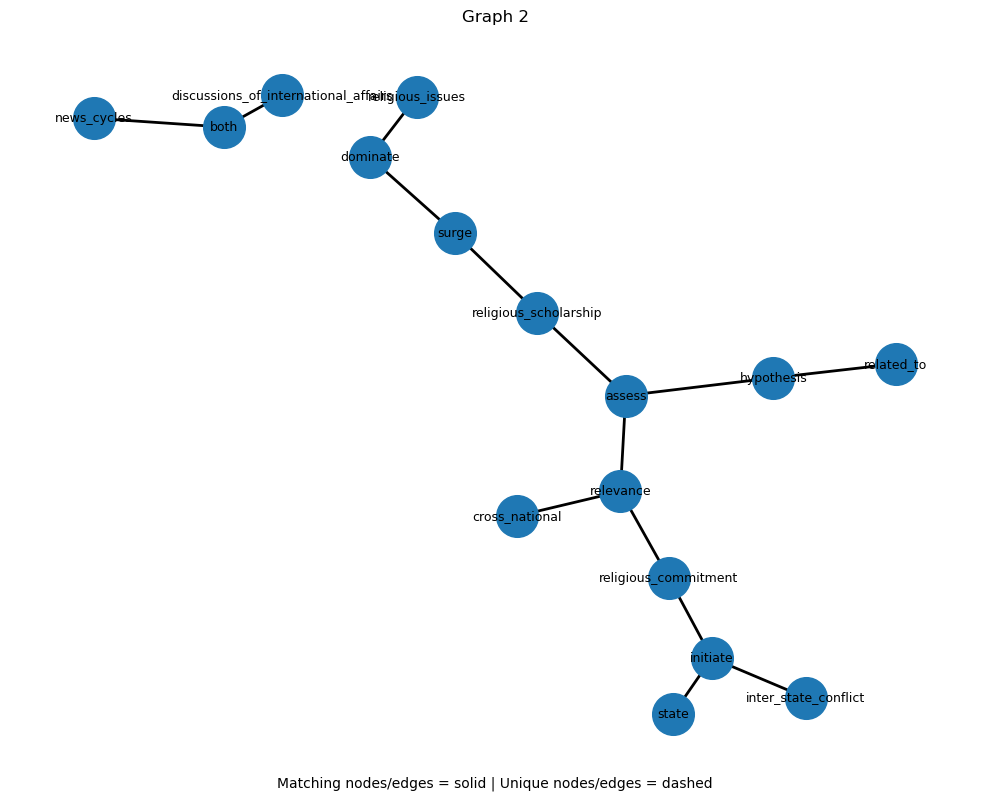

In [12]:
#COMPARE TWO GRAPHS
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path


def compare_graphml_files(file1, file2):
    file1 = Path(file1)
    file2 = Path(file2)

    # Check files exist
    if not file1.exists():
        print(f"File not found: {file1}")
        return
    if not file2.exists():
        print(f"File not found: {file2}")
        return

    # Load graphs
    try:
        G1 = nx.read_graphml(file1)
        G2 = nx.read_graphml(file2)
    except Exception as e:
        print(f"Error reading GraphML files: {e}")
        return

    print(f"\nLoaded Graph 1: {file1.name}")
    print(f"Loaded Graph 2: {file2.name}")

    
    # Compare nodes
    nodes1 = set(G1.nodes())
    nodes2 = set(G2.nodes())

    matching_nodes = nodes1 & nodes2
    nodes_only_in_G1 = nodes1 - nodes2
    nodes_only_in_G2 = nodes2 - nodes1

    print("\n--- NODE COMPARISON ---")
    if matching_nodes:
        print("Matching nodes:")
        for node in sorted(matching_nodes):
            print(f"  {node}")
    else:
        print("No matching nodes found.")

    if nodes_only_in_G1:
        print("\nNodes only in first graph:")
        for node in sorted(nodes_only_in_G1):
            print(f"  {node}")

    if nodes_only_in_G2:
        print("\nNodes only in second graph:")
        for node in sorted(nodes_only_in_G2):
            print(f"  {node}")

    
    # Compare edges
    edges1 = set(G1.edges())
    edges2 = set(G2.edges())

    matching_edges = edges1 & edges2
    edges_only_in_G1 = edges1 - edges2
    edges_only_in_G2 = edges2 - edges1

    print("\n--- EDGE COMPARISON ---")
    if matching_edges:
        print("Matching edges:")
        for edge in sorted(matching_edges):
            print(f"  {edge}")
    else:
        print("No matching edges found.")

    if edges_only_in_G1:
        print("\nEdges only in first graph:")
        for edge in sorted(edges_only_in_G1):
            print(f"  {edge}")

    if edges_only_in_G2:
        print("\nEdges only in second graph:")
        for edge in sorted(edges_only_in_G2):
            print(f"  {edge}")

    
    # Summary
    print("\n--- SUMMARY ---")
    print(f"Graph 1: {G1.number_of_nodes()} nodes, {G1.number_of_edges()} edges")
    print(f"Graph 2: {G2.number_of_nodes()} nodes, {G2.number_of_edges()} edges")

    if nodes1 == nodes2 and edges1 == edges2:
        print("The two graphs are structurally identical.")
    else:
        print("The two graphs are NOT structurally identical.")

    # Visual comparison
    # Match layout: compute positions from Graph1 and map them to Graph2
    pos1 = nx.spring_layout(G1, seed=42)
    # Initialize pos2 with pos1 so shared nodes keep the same positions
    pos2_init = pos1.copy()
    # Keep nodes from G1 fixed, compute positions for remaining nodes in G2
    fixed_nodes = list(pos1.keys())
    pos2 = nx.spring_layout(G2, pos=pos2_init, fixed=fixed_nodes, seed=42)

    # -------- Graph 1 (separate figure) --------
    plt.figure(figsize=(10, 8))
    g1_match_nodes = list(matching_nodes)
    g1_unique_nodes = list(nodes_only_in_G1)

    g1_match_edges = list(matching_edges)
    g1_unique_edges = list(edges_only_in_G1)

    nx.draw_networkx_edges(G1, pos1, edgelist=g1_match_edges, width=2)
    nx.draw_networkx_edges(G1, pos1, edgelist=g1_unique_edges, width=2.5, style="dashed")

    nx.draw_networkx_nodes(G1, pos1, nodelist=g1_match_nodes, node_size=900)
    nx.draw_networkx_nodes(G1, pos1, nodelist=g1_unique_nodes, node_size=900)

    nx.draw_networkx_labels(G1, pos1, font_size=9)
    plt.title("Graph 1")
    plt.axis("off")
    plt.figtext(0.5, 0.01, "Matching nodes/edges = solid | Unique nodes/edges = dashed", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

    # -------- Graph 2 (separate figure) --------
    plt.figure(figsize=(10, 8))
    g2_match_nodes = list(matching_nodes)
    g2_unique_nodes = list(nodes_only_in_G2)

    g2_match_edges = list(matching_edges)
    g2_unique_edges = list(edges_only_in_G2)

    nx.draw_networkx_edges(G2, pos2, edgelist=g2_match_edges, width=2)
    nx.draw_networkx_edges(G2, pos2, edgelist=g2_unique_edges, width=2.5, style="dashed")

    nx.draw_networkx_nodes(G2, pos2, nodelist=g2_match_nodes, node_size=900)
    nx.draw_networkx_nodes(G2, pos2, nodelist=g2_unique_nodes, node_size=900)

    nx.draw_networkx_labels(G2, pos2, font_size=9)
    plt.title("Graph 2")
    plt.axis("off")
    plt.figtext(0.5, 0.01, "Matching nodes/edges = solid | Unique nodes/edges = dashed", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()


# GraphML file paths
file1 = r"C:\WorldView\worldview\w0rldview\test2.graphml"  # Mac & Windows
file2 = r"C:\WorldView\worldview\w0rldview\test1.graphml"  # Mac & Windows

compare_graphml_files(file1, file2)